In [134]:
import numpy as np
from scipy.special import comb
from typing import Callable, Tuple, Union
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import shap
import pandas as pd
import time
from sklearn.metrics import mean_absolute_error
from sklearn.cluster import KMeans
import itertools


import numpy as np
from itertools import combinations
from scipy.special import comb
from typing import Callable, Tuple
from math import factorial

def exact_shapley_values(
    model: Callable[[np.ndarray], np.ndarray],
    test_instance: np.ndarray,
    background_data: np.ndarray
) -> Tuple[np.ndarray, float]:
    """
    Compute exact SHAP values for a single instance by considering all possible subsets of features.

    Args:
        model (Callable[[np.ndarray], np.ndarray]): Prediction function for the trained model.
        test_instance (np.ndarray): 1D array of the instance to explain.
        background_data (np.ndarray): 2D array representing the background dataset.

    Returns:
        Tuple[np.ndarray, float]: SHAP values and the baseline prediction.
    """
    num_features = test_instance.shape[0]
    baseline_prediction = np.mean(model(background_data))
    shap_values = np.zeros(num_features)

    # Precompute baseline feature values (mean of background data)
    baseline_features = np.mean(background_data, axis=0)

    # Precompute factorials for weight calculation
    M_fact = factorial(num_features)
    factorials = [factorial(k) for k in range(num_features + 1)]

    # Enumerate all subsets of features
    for subset_size in range(num_features + 1):
        for subset in combinations(range(num_features), subset_size):
            subset_set = set(subset)

            # Create the masked instance for the subset
            subset_mask = np.array([1 if i in subset_set else 0 for i in range(num_features)])
            instance_with_subset = subset_mask * test_instance + (1 - subset_mask) * baseline_features
            prediction_with_subset = model(instance_with_subset.reshape(1, -1))[0]

            # Iterate through all features not in the subset
            for feature in range(num_features):
                if feature in subset_set:
                    continue  # Skip if feature is already in the subset

                # Add feature to subset and create the corresponding instance
                subset_with_feature = subset_set | {feature}
                feature_mask = np.array([1 if i in subset_with_feature else 0 for i in range(num_features)])
                instance_with_feature = feature_mask * test_instance + (1 - feature_mask) * baseline_features
                prediction_with_feature = model(instance_with_feature.reshape(1, -1))[0]

                # Compute marginal contribution
                marginal_contribution = prediction_with_feature - prediction_with_subset

                # Compute Shapley weight
                s = len(subset_set)
                weight = (factorials[s] * factorials[num_features - s - 1]) / M_fact

                # Update SHAP value for the feature
                shap_values[feature] += weight * marginal_contribution

    return shap_values, baseline_prediction


    
def compute_baseline_exact(
    background_data: np.ndarray, 
    substitute_mean_for_continuous: bool, 
    substitute_dummy_flip: bool,
    test_instance: np.ndarray
) -> np.ndarray:
    """
    Compute the baseline substitution for exact Shapley computation.

    Args:
        background_data (np.ndarray): Background data for feature replacement (2D array).
        substitute_mean_for_continuous (bool): Whether to use mean for continuous features.
        substitute_dummy_flip (bool): Whether to flip dummy variables when excluding.
        test_instance (np.ndarray): The test instance being explained.

    Returns:
        np.ndarray: Baseline substitution vector (1D array).
    """
    num_features = background_data.shape[1]
    baseline_samples = np.zeros(num_features)

    # Identify feature types
    is_continuous = np.array([np.issubdtype(background_data[:, i].dtype, np.floating) for i in range(num_features)])
    is_binary = np.array([np.array_equal(np.unique(background_data[:, i]), [0, 1]) for i in range(num_features)])

    # Compute means
    means = np.mean(background_data, axis=0)

    # Substitutions
    if substitute_mean_for_continuous:
        baseline_samples[is_continuous] = means[is_continuous]

    if substitute_dummy_flip:
        binary_features = is_binary
        if np.any(binary_features):
            baseline_samples[binary_features] = 1 - test_instance[binary_features]

    # Handle remaining features
    remaining = ~(is_continuous | is_binary)
    if np.any(remaining):
        baseline_samples[remaining] = means[remaining]

    return baseline_samples

def vectorized_weighted_shap(
    model: Callable[[np.ndarray], np.ndarray],
    test_instance: np.ndarray,
    background_data: np.ndarray,
    num_samples: Union[int, str] = "auto",
    normalize_weights: bool = True,
    use_random_sampling: bool = True,
    use_paired_sampling: bool = False,
    include_intermediate_factor: bool = True,
    use_random_baseline: bool = True,
    substitute_mean_for_continuous: bool = True,
    substitute_dummy_flip: bool = True,
    exact_shap: bool = False  # New parameter for exact Shapley computation
) -> Tuple[np.ndarray, float]:
    """
    Compute Shapley values efficiently using weighted sampling and vectorized operations.
    Can also compute exact Shapley values by enumerating all subsets.

    Args:
        model (Callable[[np.ndarray], np.ndarray]): Prediction function of the trained model.
        test_instance (np.ndarray): Single test instance to explain (1D array).
        background_data (np.ndarray): Background data for feature replacement (2D array).
        num_samples (int or str, optional): Number of subsets to sample. Default is "auto".
        normalize_weights (bool, optional): Whether to normalize kernel weights. Default is True.
        use_random_sampling (bool, optional): Use random subsets instead of weighting-based sampling. Default is True.
        use_paired_sampling (bool, optional): Whether to use paired sampling for subsets. Default is False.
        include_intermediate_factor (bool, optional): Whether to apply intermediate weighting adjustment. Default is True.
        use_random_baseline (bool, optional): Use random sampling from background data for baseline substitution. Default is True.
        substitute_mean_for_continuous (bool, optional): Whether to use mean for continuous features. Default is True.
        substitute_dummy_flip (bool, optional): Whether to flip dummy variables when excluding. Default is True.
        exact_shap (bool, optional): Whether to compute exact Shapley values by enumerating all subsets. Default is False.

    Returns:
        Tuple[np.ndarray, float]: 
            - shap_values (np.ndarray): Array of Shapley values for each feature.
            - baseline_prediction (float): Average model prediction on background data.
    """
    # Input validation
    if not callable(model):
        raise ValueError("`model` must be a callable function.")
    if test_instance.ndim != 1:
        raise ValueError("`test_instance` must be a 1D array.")
    if background_data.ndim != 2:
        raise ValueError("`background_data` must be a 2D array.")
    if isinstance(num_samples, str) and num_samples != "auto":
        raise ValueError("`num_samples` must be an integer or 'auto'.")
    if isinstance(num_samples, int) and num_samples <= 0:
        raise ValueError("`num_samples` must be a positive integer.")
    if exact_shap and test_instance.shape[0] > 20:
        raise ValueError("Exact Shapley computation is only feasible for <= 20 features.")

    num_features = test_instance.shape[0]

    # Exact Shapley computation
    if exact_shap:
        shap_values = np.zeros(num_features)
        baseline_prediction = np.mean(model(background_data))
        prediction = model(test_instance.reshape(1, -1))[0]
        
        # Enumerate all possible subsets
        all_subsets = list(itertools.chain.from_iterable(
            itertools.combinations(range(num_features), r) for r in range(num_features + 1)
        ))
        
        for subset in all_subsets:
            subset_set = set(subset)
            subset_mask = np.array([1 if j in subset_set else 0 for j in range(num_features)])
            
            # Substitute excluded features
            substituted = subset_mask * test_instance + (1 - subset_mask) * compute_baseline_exact(
                background_data, 
                substitute_mean_for_continuous, 
                substitute_dummy_flip, 
                test_instance
            )
            prediction_subset = model(substituted.reshape(1, -1))[0]
            
            # Features not in the subset
            features_not_in_subset = set(range(num_features)) - subset_set
            
            for feature in features_not_in_subset:
                # Create a new subset with the feature added
                new_subset_set = subset_set.union({feature})
                new_subset_mask = np.array([1 if j in new_subset_set else 0 for j in range(num_features)])
                
                # Substitute excluded features
                substituted_plus = new_subset_mask * test_instance + (1 - new_subset_mask) * compute_baseline_exact(
                    background_data, 
                    substitute_mean_for_continuous, 
                    substitute_dummy_flip, 
                    test_instance
                )
                prediction_subset_plus = model(substituted_plus.reshape(1, -1))[0]
                
                # Marginal contribution
                marginal_contribution = prediction_subset_plus - prediction_subset
                
                # Shapley weight
                s = len(subset_set)
                shap_weight = comb(num_features -1, s) / comb(num_features, s +1)
                
                shap_values[feature] += marginal_contribution * shap_weight

        return shap_values, baseline_prediction

    # Set num_samples to exact number if "auto" and exact_shap is False
    if num_samples == "auto":
        num_samples = 2 * num_features + 2048

    # Compute subset sizes
    subset_sizes = np.arange(1, num_features)
    
    # Correct Shapley weight calculation for approximate method
    subset_weights = (subset_sizes + 1) / num_features  # Simplified weight formula for approximation
    if include_intermediate_factor:
        intermediate_factors = 1 / (1 + np.abs(num_features / 2 - subset_sizes))
        subset_weights *= intermediate_factors
    if normalize_weights:
        subset_weights /= subset_weights.sum()
    
    # Cumulative weights for weighted sampling
    cumulative_weights = np.cumsum(subset_weights)
    
    # Sample subset sizes
    if use_random_sampling:
        sampled_sizes = np.random.randint(1, num_features, size=num_samples)
    else:
        rand_vals = np.random.random(size=num_samples)
        sampled_sizes = np.searchsorted(cumulative_weights, rand_vals) + 1
    
    # Compute weights for sampled subsets
    sampled_weights = (sampled_sizes + 1) / num_features  # Simplified weight formula for approximation
    if include_intermediate_factor:
        intermediate_factors = 1 / (1 + np.abs(num_features / 2 - sampled_sizes))
        sampled_weights *= intermediate_factors
    if normalize_weights:
        sampled_weights /= sampled_weights.sum()
    
    # Create subsets
    subsets = np.zeros((num_samples, num_features), dtype=int)
    for i, size in enumerate(sampled_sizes):
        subsets[i, :size] = 1
        np.random.shuffle(subsets[i])
    
    # Handle paired sampling
    if use_paired_sampling:
        complements = 1 - subsets
        subsets = np.vstack((subsets, complements))
        complemented_weights = sampled_weights.copy()
        if normalize_weights:
            complemented_weights = np.concatenate((sampled_weights, complemented_weights))
            complemented_weights /= complemented_weights.sum()
        else:
            complemented_weights = np.concatenate((sampled_weights, complemented_weights))
        weights = complemented_weights
    else:
        weights = sampled_weights
    
    # Prepare substitution matrix
    test_instance_matrix = np.tile(test_instance, (subsets.shape[0], 1))
    
    # Identify feature types
    is_continuous = np.array([np.issubdtype(background_data[:, i].dtype, np.floating) for i in range(num_features)])
    is_binary = np.array([np.array_equal(np.unique(background_data[:, i]), [0, 1]) for i in range(num_features)])
    
    # Compute means for continuous and remaining features
    means = np.mean(background_data, axis=0)
    
    # Initialize baseline_samples with means
    baseline_samples = np.tile(means, (subsets.shape[0], 1))
    
    # Handle binary features with substitute_dummy_flip
    if substitute_dummy_flip:
        binary_features = is_binary
        if np.any(binary_features):
            # Create a mask for excluded binary features
            mask_excluded_binary = (subsets == 0)[:, binary_features]
            # Flip binary features where excluded
            baseline_samples[:, binary_features] = np.where(
                mask_excluded_binary,
                1 - test_instance[binary_features],
                baseline_samples[:, binary_features]
            )
    
    # Handle continuous features where substitute_mean_for_continuous=False and use_random_baseline=True
    if not substitute_mean_for_continuous and use_random_baseline:
        continuous_features = is_continuous
        if np.any(continuous_features):
            mask_excluded_continuous = (subsets == 0)[:, continuous_features]
            num_continuous = continuous_features.sum()
            # Sample random background data indices for continuous features
            sampled_indices = np.random.randint(0, background_data.shape[0], size=(num_samples, num_continuous))
            sampled_features = np.where(continuous_features)[0]
            sampled_values = background_data[sampled_indices, sampled_features]  # Shape: (num_samples, num_continuous)
            # Replace with sampled values where features are excluded
            baseline_samples[:, sampled_features] = np.where(
                mask_excluded_continuous,
                sampled_values,
                baseline_samples[:, sampled_features]
            )
    
    # Handle remaining features where use_random_baseline=True
    if use_random_baseline:
        remaining = ~(is_continuous | is_binary)
        if np.any(remaining):
            mask_excluded_remaining = (subsets == 0)[:, remaining]
            num_remaining = remaining.sum()
            # Sample random background data indices for remaining features
            sampled_indices = np.random.randint(0, background_data.shape[0], size=(num_samples, num_remaining))
            sampled_features = np.where(remaining)[0]
            sampled_values = background_data[sampled_indices, sampled_features]  # Shape: (num_samples, num_remaining)
            # Replace with sampled values where features are excluded
            baseline_samples[:, sampled_features] = np.where(
                mask_excluded_remaining,
                sampled_values,
                baseline_samples[:, sampled_features]
            )
    
    # Create substituted matrix
    substituted_matrix = subsets * test_instance_matrix + (1 - subsets) * baseline_samples
    
    # Compute predictions
    predictions = model(substituted_matrix)
    
    # Initialize Shapley values
    shapley_values = np.zeros(num_features)
    
    # Compute Shapley values for each feature
    for feature_idx in range(num_features):
        mask_without_feature = subsets[:, feature_idx] == 0
        if not np.any(mask_without_feature):
            continue  # Skip if no subsets exclude this feature

        # Compute difference when feature is included
        subsets_with_feature = subsets[mask_without_feature].copy()
        subsets_with_feature[:, feature_idx] = 1
        substituted_with_feature = subsets_with_feature * test_instance_matrix[mask_without_feature] + \
                                   (1 - subsets_with_feature) * baseline_samples[mask_without_feature]
        predictions_with_feature = model(substituted_with_feature)
        delta_predictions = predictions_with_feature - predictions[mask_without_feature]
        shapley_values[feature_idx] = np.average(delta_predictions, weights=weights[mask_without_feature])
    
    # Compute baseline prediction
    baseline_prediction = np.mean(model(background_data))
    
    # Compute actual prediction
    prediction = model(test_instance.reshape(1, -1))[0]
    
    # Residual adjustment to ensure efficiency property
    total_shap = np.sum(shapley_values)
    expected_diff = prediction - baseline_prediction
    residual = expected_diff - total_shap
    
    if np.abs(residual) > 1e-6:
        shapley_values += residual / num_features  # Distribute uniformly
    
    return shapley_values, baseline_prediction

def weighted_regression_shap(
    model: Callable[[np.ndarray], np.ndarray],
    test_instance: np.ndarray,
    background_data: np.ndarray,
    num_samples: Union[int, str] = "auto",
    normalize_weights: bool = True,
    include_intermediate_factor: bool = False
) -> Tuple[np.ndarray, float]:
    """
    Compute Shapley values using weighted least-squares regression with explicit subset construction.

    Args:
        model (Callable[[np.ndarray], np.ndarray]): Prediction function of the trained model.
        test_instance (np.ndarray): Single test instance to explain (1D array).
        background_data (np.ndarray): Background data for feature replacement (2D array).
        num_samples (int or str, optional): Number of subsets to sample. Default is "auto".
        normalize_weights (bool, optional): Normalize kernel weights. Default is True.
        include_intermediate_factor (bool, optional): Include intermediate factor for kernel weights. Default is False.

    Returns:
        Tuple[np.ndarray, float]: 
            - shap_values (np.ndarray): Array of Shapley values for each feature.
            - baseline_prediction (float): Model's average prediction on background data.
    """
    num_features = test_instance.shape[0]

    def shapley_kernel(M: int, s: int) -> float:
        """
        Calculate the Shapley kernel weight for a subset of size s.

        Args:
            M (int): Total number of features.
            s (int): Size of the subset.

        Returns:
            float: Shapley weight for the subset.
        """
        if s == 0 or s == M:
            return 0.0
        weight = (s + 1) / M  # Correct Shapley weight
        if include_intermediate_factor:
            intermediate_factor = 1 / (1 + abs(M / 2 - s))
            weight *= intermediate_factor
        return weight

    # Compute baseline prediction
    baseline_prediction = np.mean(model(background_data))

    # Generate all subsets (powerset)
    subsets = list(itertools.chain.from_iterable(
        itertools.combinations(range(num_features), r) for r in range(num_features + 1)
    ))

    # Prepare matrices
    num_subsets = len(subsets)
    X = np.zeros((num_subsets, num_features + 1))
    X[:, -1] = 1  # Intercept term
    weights = np.zeros(num_subsets)
    V = np.tile(np.mean(background_data, axis=0), (num_subsets, 1))  # Initialize with baseline

    for i, subset in enumerate(subsets):
        subset = list(subset)
        if subset:
            V[i, subset] = test_instance[subset]  # Replace subset features with test instance values
            X[i, subset] = 1  # Mark active features
        weights[i] = shapley_kernel(num_features, len(subset))  # Assign Shapley weight

    # Filter out subsets with zero weight
    valid = weights > 0
    X = X[valid]
    V = V[valid]
    weights = weights[valid]

    # Compute predictions for all valid subsets
    y = model(V)

    if normalize_weights:
        weights /= np.sum(weights)

    # Apply weighted least squares regression
    wsq = np.sqrt(weights)
    X_weighted = X * wsq[:, np.newaxis]
    y_weighted = y * wsq
    coef, residuals, rank, s = np.linalg.lstsq(X_weighted, y_weighted, rcond=None)

    shap_values = coef[:-1]  # Feature contributions
    intercept = coef[-1]  # Baseline/intercept

    return shap_values, intercept


# ======================= MAIN SCRIPT =======================

# Generate a regression dataset
X, y = make_regression(n_samples=10000, n_features=10, noise=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Perform K-means clustering to obtain background data
kmeans = KMeans(n_clusters=100, random_state=42)
kmeans.fit(X_train)
background = kmeans.cluster_centers_

# Select a test instance
test_instance = X_test[0]

# Compute SHAP values using TreeExplainer
start_time = time.time()
tree_explainer = shap.TreeExplainer(regressor)
tree_shap_values = tree_explainer.shap_values(test_instance.reshape(1, -1))[0]
# Handle possible DeprecationWarning by ensuring expected_value is a scalar
if isinstance(tree_explainer.expected_value, np.ndarray):
    tree_baseline = float(tree_explainer.expected_value[0])
else:
    tree_baseline = float(tree_explainer.expected_value)
tree_time = time.time() - start_time

# Compute SHAP values using KernelExplainer
start_time = time.time()
kernel_explainer = shap.KernelExplainer(regressor.predict, background)
kernel_shap_values = kernel_explainer.shap_values(test_instance.reshape(1, -1))[0]
if isinstance(kernel_explainer.expected_value, np.ndarray):
    kernel_baseline = float(kernel_explainer.expected_value[0])
else:
    kernel_baseline = float(kernel_explainer.expected_value)
kernel_time = time.time() - start_time

# Compute SHAP values using vectorized_weighted_shap (approximate)
start_time = time.time()
custom_shap_values, custom_baseline = vectorized_weighted_shap(
    model=regressor.predict,
    test_instance=test_instance,
    background_data=background,
    num_samples="auto",
    normalize_weights=True,
    use_random_sampling=True,
    use_paired_sampling=False,
    include_intermediate_factor=True,
    use_random_baseline=True,
    substitute_mean_for_continuous=False,  # Adjust based on your needs
    substitute_dummy_flip=False,           # Adjust based on your needs
    exact_shap=False                       # Set to True for exact Shapley values (if feasible)
)
custom_time = time.time() - start_time

# Compute SHAP values using vectorized_weighted_shap (exact)
start_time = time.time()
exact_shap_values, exact_baseline = exact_shapley_values(
    model=regressor.predict,
    test_instance=test_instance,
    background_data=background
)

exact_time = time.time() - start_time

# Compute SHAP values using weighted_regression_shap
start_time = time.time()
regression_shap_values, regression_baseline = weighted_regression_shap(
    model=regressor.predict,
    test_instance=test_instance,
    background_data=background,
    num_samples="auto",
    normalize_weights=True,
    include_intermediate_factor=False,  # Ensure consistency
)
regression_time = time.time() - start_time

# Compute MAE for Kernel, Custom, Regression, and Exact SHAP with TreeExplainer as the reference
reference_mae = exact_shap_values
tree_mae = mean_absolute_error(reference_mae, tree_shap_values)  # Should be 0
kernel_mae = mean_absolute_error(reference_mae, kernel_shap_values)
custom_mae = mean_absolute_error(reference_mae, custom_shap_values)
regression_mae = mean_absolute_error(reference_mae, regression_shap_values)
exact_mae = mean_absolute_error(reference_mae, exact_shap_values)

# Display results
results = pd.DataFrame({
    "Feature": [f"Feature {i+1}" for i in range(X.shape[1])],
    "TreeExplainer SHAP": np.round(tree_shap_values, 4),
    "KernelExplainer SHAP": np.round(kernel_shap_values, 4),
    "Custom SHAP": np.round(custom_shap_values, 4),
    "Regression SHAP": np.round(regression_shap_values, 4),
    "Exact Shapley SHAP": np.round(exact_shap_values, 4),
})

# Append additional rows for Baseline, Sum, Prediction, Computation Time, and MAE
additional_rows = pd.DataFrame([
    {"Feature": "Baseline", 
     "TreeExplainer SHAP": np.round(tree_baseline, 4),
     "KernelExplainer SHAP": np.round(kernel_baseline, 4),
     "Custom SHAP": np.round(custom_baseline, 4),
     "Regression SHAP": np.round(regression_baseline, 4),
     "Exact Shapley SHAP": np.round(exact_baseline, 4)},
    
    {"Feature": "Sum", 
     "TreeExplainer SHAP": np.round(np.sum(tree_shap_values) + tree_baseline, 4),
     "KernelExplainer SHAP": np.round(np.sum(kernel_shap_values) + kernel_baseline, 4),
     "Custom SHAP": np.round(np.sum(custom_shap_values) + custom_baseline, 4),
     "Regression SHAP": np.round(np.sum(regression_shap_values) + regression_baseline, 4),
     "Exact Shapley SHAP": np.round(np.sum(exact_shap_values) + exact_baseline, 4)},
    
    {"Feature": "Prediction (Test Instance)", 
     "TreeExplainer SHAP": np.round(regressor.predict(test_instance.reshape(1, -1))[0], 4),
     "KernelExplainer SHAP": np.round(regressor.predict(test_instance.reshape(1, -1))[0], 4),
     "Custom SHAP": np.round(regressor.predict(test_instance.reshape(1, -1))[0], 4),
     "Regression SHAP": np.round(regressor.predict(test_instance.reshape(1, -1))[0], 4),
     "Exact Shapley SHAP": np.round(regressor.predict(test_instance.reshape(1, -1))[0], 4)},
    
    {"Feature": "Computation Time (s)", 
     "TreeExplainer SHAP": np.round(tree_time, 4),
     "KernelExplainer SHAP": np.round(kernel_time, 4),
     "Custom SHAP": np.round(custom_time, 4),
     "Regression SHAP": np.round(regression_time, 4),
     "Exact Shapley SHAP": np.round(exact_time, 4)},
    
    {"Feature": "MAE (vs TreeExplainer)", 
     "TreeExplainer SHAP": np.round(tree_mae, 4),
     "KernelExplainer SHAP": np.round(kernel_mae, 4),
     "Custom SHAP": np.round(custom_mae, 4),
     "Regression SHAP": np.round(regression_mae, 4),
     "Exact Shapley SHAP": np.round(exact_mae, 4)},
])

# Concatenate results and additional rows
results = pd.concat([results, additional_rows], ignore_index=True)

# Display the results
results

  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,TreeExplainer SHAP,KernelExplainer SHAP,Custom SHAP,Regression SHAP,Exact Shapley SHAP
0,Feature 1,41.3619,41.0490,40.1207,44.0203,43.9547
1,Feature 2,-6.3164,-6.3479,-6.7123,-7.0107,-6.9583
2,Feature 3,-43.9518,-44.0539,-44.4115,-38.5686,-38.9238
3,Feature 4,-4.7647,-5.1335,-4.8039,-3.4954,-2.9930
4,Feature 5,-0.0132,0.1103,0.0969,-0.7034,-0.1442
5,Feature 6,-11.9577,-10.7593,-9.5512,-9.6628,-9.7197
6,Feature 7,-58.0380,-54.3327,-55.1263,-30.6137,-33.1631
7,Feature 8,-1.2545,-0.9950,-0.9705,-0.3551,-0.6781
8,Feature 9,-2.3063,-2.6111,-2.5465,-0.7620,-0.6908
9,Feature 10,66.1886,66.0871,66.9175,63.2791,64.1798


In [280]:
import numpy as np
import itertools
from typing import Callable, Union, Tuple
from math import comb

def compute_baseline_exact(
    background_data: np.ndarray, 
    substitute_mean_for_continuous: bool, 
    substitute_dummy_flip: bool,
    test_instance: np.ndarray
) -> np.ndarray:
    """
    Compute a single baseline substitution vector for exact Shapley computation.
    This function is called inside vectorized_weighted_shap when exact_shap=True
    and enumerating subsets.

    Args:
        background_data (np.ndarray): Background data (shape: [n_samples, n_features]).
        substitute_mean_for_continuous (bool): If True, use mean for continuous features.
        substitute_dummy_flip (bool): If True, for binary features, set excluded to 1 - test_instance.
        test_instance (np.ndarray): Single test instance (1D array).

    Returns:
        np.ndarray: A single baseline vector (1D).
    """
    num_features = background_data.shape[1]
    baseline_vector = np.zeros(num_features)

    # Detect feature types
    is_continuous = np.array([np.issubdtype(background_data[:, i].dtype, np.floating) 
                              for i in range(num_features)])
    is_binary = np.array([np.array_equal(np.unique(background_data[:, i]), [0, 1]) 
                          for i in range(num_features)])

    means = np.mean(background_data, axis=0)

    # 1. Continuous features
    if substitute_mean_for_continuous:
        baseline_vector[is_continuous] = means[is_continuous]

    # 2. Binary (dummy) features
    if substitute_dummy_flip:
        binary_features = is_binary
        if np.any(binary_features):
            # Flip excluded binary features to 1 - test_instance
            baseline_vector[binary_features] = 1 - test_instance[binary_features]

    # 3. Remaining features
    remaining = ~(is_continuous | is_binary)
    if np.any(remaining):
        # Use mean for any leftover features (could be categorical, etc.)
        baseline_vector[remaining] = means[remaining]

    return baseline_vector


def vectorized_weighted_shap(
    model: Callable[[np.ndarray], np.ndarray],
    test_instance: np.ndarray,
    background_data: np.ndarray,
    num_samples: Union[int, str] = "auto",
    normalize_weights: bool = True,
    use_random_sampling: bool = True,
    use_paired_sampling: bool = False,
    include_intermediate_factor: bool = True,
    use_random_baseline: bool = True,
    substitute_mean_for_continuous: bool = True,
    substitute_dummy_flip: bool = True,
    exact_shap: bool = False  # Whether to do exact enumeration over subsets
) -> Tuple[np.ndarray, float]:
    """
    Compute Shapley values efficiently using weighted sampling and vectorized operations.
    Can also compute exact Shapley values by enumerating all subsets, if exact_shap=True.

    Args:
        model (Callable[[np.ndarray], np.ndarray]): Prediction function of the trained model.
        test_instance (np.ndarray): Single test instance to explain (1D array).
        background_data (np.ndarray): Background data (2D array).
        num_samples (int or str): Number of subsets to sample (int) or "auto".
        normalize_weights (bool): Whether to normalize subset-size weights.
        use_random_sampling (bool): If True, sample subset sizes randomly; else use weighting cdf.
        use_paired_sampling (bool): If True, also add complement subsets for each sample.
        include_intermediate_factor (bool): Whether to apply an additional weighting factor 
                                            near subset_size ~ num_features/2.
        use_random_baseline (bool): If True, sample from background data for excluded features.
        substitute_mean_for_continuous (bool): If True, use mean for excluded continuous features.
        substitute_dummy_flip (bool): If True, flip 0->1 or 1->0 for excluded binary features.
        exact_shap (bool): If True, enumerate all subsets (feasible up to ~20 features).

    Returns:
        Tuple[np.ndarray, float]:
            - shap_values (np.ndarray): Shapley values for each feature (1D array).
            - baseline_prediction (float): Mean model prediction over background_data.
    """

    # Basic validations
    if not callable(model):
        raise ValueError("`model` must be a callable function.")
    if test_instance.ndim != 1:
        raise ValueError("`test_instance` must be a 1D array.")
    if background_data.ndim != 2:
        raise ValueError("`background_data` must be a 2D array.")
    if isinstance(num_samples, str) and num_samples != "auto":
        raise ValueError("`num_samples` must be an integer or 'auto'.")
    if isinstance(num_samples, int) and num_samples <= 0:
        raise ValueError("`num_samples` must be a positive integer.")
    if exact_shap and test_instance.shape[0] > 20:
        raise ValueError("Exact Shapley computation is only feasible for <= 20 features.")

    num_features = test_instance.shape[0]

    # If exact Shap is requested, do the (potentially expensive) enumeration:
    if exact_shap:
        shap_values = np.zeros(num_features)
        # Baseline = average model prediction on background
        baseline_prediction = np.mean(model(background_data))

        # Prediction for the test_instance itself
        prediction = model(test_instance.reshape(1, -1))[0]

        # Enumerate all subsets
        all_subsets = list(
            itertools.chain.from_iterable(
                itertools.combinations(range(num_features), r) 
                for r in range(num_features + 1)
            )
        )

        # For each subset, compute the difference when adding each excluded feature
        for subset in all_subsets:
            subset_set = set(subset)
            subset_mask = np.array([1 if j in subset_set else 0 for j in range(num_features)])

            # Build substituted instance for "subset"
            substituted = subset_mask * test_instance + (1 - subset_mask) * compute_baseline_exact(
                background_data, 
                substitute_mean_for_continuous, 
                substitute_dummy_flip, 
                test_instance
            )
            prediction_subset = model(substituted.reshape(1, -1))[0]

            # Features not in the subset
            features_not_in_subset = set(range(num_features)) - subset_set

            for feature in features_not_in_subset:
                # New subset with the feature added
                new_subset_set = subset_set.union({feature})
                new_subset_mask = np.array([1 if j in new_subset_set else 0 
                                            for j in range(num_features)])
                
                substituted_plus = new_subset_mask * test_instance + \
                                   (1 - new_subset_mask) * compute_baseline_exact(
                    background_data, 
                    substitute_mean_for_continuous, 
                    substitute_dummy_flip, 
                    test_instance
                )
                prediction_subset_plus = model(substituted_plus.reshape(1, -1))[0]

                # Marginal contribution
                marginal_contribution = prediction_subset_plus - prediction_subset

                # Shapley weight for that step
                s = len(subset_set)
                shap_weight = comb(num_features - 1, s) / comb(num_features, s + 1)

                shap_values[feature] += marginal_contribution * shap_weight

        return shap_values, baseline_prediction

    # ===========================
    # APPROXIMATE SHAP METHOD
    # ===========================

    # 1) Number of subsets (num_samples)
    if num_samples == "auto":
        # Arbitrary default: 2*M + 2048
        num_samples = 2 * num_features + 2048

    # 2) Precompute subset sizes + weighting
    subset_sizes = np.arange(1, num_features)  # 1..(M-1)
    # Simple weighting formula (your approach)
    subset_weights = (subset_sizes + 1) / num_features

    if include_intermediate_factor:
        # Extra factor near half the features
        # This is purely heuristic: it increases weight for subsets near M/2
        intermediate_factors = 1 / (1 + np.abs(num_features / 2 - subset_sizes))
        subset_weights *= intermediate_factors

    if normalize_weights:
        subset_weights /= subset_weights.sum()

    # Convert to cumulative distribution for subset sizes
    cumulative_weights = np.cumsum(subset_weights)

    # 3) Sample subset sizes
    if use_random_sampling:
        # uniform random integer in [1, num_features)
        sampled_sizes = np.random.randint(1, num_features, size=num_samples)
    else:
        # sampling from subset_size distribution via cdf
        rand_vals = np.random.random(size=num_samples)
        sampled_sizes = np.searchsorted(cumulative_weights, rand_vals) + 1

    # Weighted formula for each sampled subset
    sampled_weights = (sampled_sizes + 1) / num_features
    if include_intermediate_factor:
        intermediate_factors = 1 / (1 + np.abs(num_features / 2 - sampled_sizes))
        sampled_weights *= intermediate_factors

    if normalize_weights:
        sampled_weights /= sampled_weights.sum()

    # 4) Create the subsets matrix
    subsets = np.zeros((num_samples, num_features), dtype=int)
    for i, size in enumerate(sampled_sizes):
        chosen = np.random.choice(num_features, size=size, replace=False)
        subsets[i, chosen] = 1

    # 5) Handle paired sampling (also add complement subsets)
    if use_paired_sampling:
        complements = 1 - subsets
        subsets = np.vstack([subsets, complements])
        new_weights = np.concatenate([sampled_weights, sampled_weights])
        if normalize_weights:
            new_weights /= new_weights.sum()
        weights = new_weights
    else:
        weights = sampled_weights

    # 6) Build the baseline samples for excluded features
    test_instance_matrix = np.tile(test_instance, (subsets.shape[0], 1))

    # Identify feature types
    is_continuous = np.array([
        np.issubdtype(background_data[:, i].dtype, np.floating) 
        for i in range(num_features)
    ])
    is_binary = np.array([
        np.array_equal(np.unique(background_data[:, i]), [0, 1]) 
        for i in range(num_features)
    ])

    # Means for continuous & fallback
    means = np.mean(background_data, axis=0)
    baseline_samples = np.tile(means, (subsets.shape[0], 1))

    # 6a) Flip binary features if exclude
    if substitute_dummy_flip:
        binary_features = is_binary
        if np.any(binary_features):
            mask_excluded_binary = (subsets == 0)[:, binary_features]
            baseline_samples[:, binary_features] = np.where(
                mask_excluded_binary,
                1 - test_instance[binary_features],
                baseline_samples[:, binary_features]
            )

    # 6b) If not using mean for continuous, and want random baseline, sample from background
    if not substitute_mean_for_continuous and use_random_baseline:
        continuous_features = is_continuous
        if np.any(continuous_features):
            mask_excluded_continuous = (subsets == 0)[:, continuous_features]
            num_cont = continuous_features.sum()

            # Randomly pick background rows
            sampled_indices = np.random.randint(
                0, background_data.shape[0], size=(subsets.shape[0], num_cont)
            )
            cont_feat_indices = np.where(continuous_features)[0]
            sampled_values = background_data[sampled_indices, cont_feat_indices]

            baseline_samples[:, cont_feat_indices] = np.where(
                mask_excluded_continuous,
                sampled_values,
                baseline_samples[:, cont_feat_indices]
            )

    # 6c) For "remaining" features (if they're not continuous and not binary),
    #     if use_random_baseline=True, sample from background
    if use_random_baseline:
        remaining = ~(is_continuous | is_binary)
        if np.any(remaining):
            mask_excluded_remaining = (subsets == 0)[:, remaining]
            num_rem = remaining.sum()

            sampled_indices = np.random.randint(
                0, background_data.shape[0], size=(subsets.shape[0], num_rem)
            )
            rem_feat_indices = np.where(remaining)[0]
            sampled_values = background_data[sampled_indices, rem_feat_indices]

            baseline_samples[:, rem_feat_indices] = np.where(
                mask_excluded_remaining,
                sampled_values,
                baseline_samples[:, rem_feat_indices]
            )

    # 7) Create final substituted matrix
    substituted_matrix = subsets * test_instance_matrix + (1 - subsets) * baseline_samples

    # 8) Model predictions for all subsets
    predictions = model(substituted_matrix)

    # 9) Compute Shapley values for each feature
    shapley_values = np.zeros(num_features)
    for feature_idx in range(num_features):
        # Find which subsets exclude this feature
        mask_without_feature = subsets[:, feature_idx] == 0
        if not np.any(mask_without_feature):
            continue

        # Create a version of subsets that "adds" the feature back in
        subsets_with_feature = subsets[mask_without_feature].copy()
        subsets_with_feature[:, feature_idx] = 1

        substituted_with_feature = \
            subsets_with_feature * test_instance_matrix[mask_without_feature] + \
            (1 - subsets_with_feature) * baseline_samples[mask_without_feature]

        predictions_with_feature = model(substituted_with_feature)

        # Delta in predictions from excluding -> including the feature
        delta_predictions = predictions_with_feature - predictions[mask_without_feature]

        # Weighted average effect for this feature
        shapley_values[feature_idx] = np.average(
            delta_predictions,
            weights=weights[mask_without_feature]
        )

    # 10) Baseline + final residual correction
    baseline_prediction = np.mean(model(background_data))
    actual_prediction = model(test_instance.reshape(1, -1))[0]

    total_shap = np.sum(shapley_values)
    expected_diff = actual_prediction - baseline_prediction
    residual = expected_diff - total_shap

    if np.abs(residual) > 1e-6:
        # Distribute the leftover among features to preserve the Shapley "efficiency" property
        shapley_values += residual / num_features

    return shapley_values, baseline_prediction

C:\Users\mnoorche\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

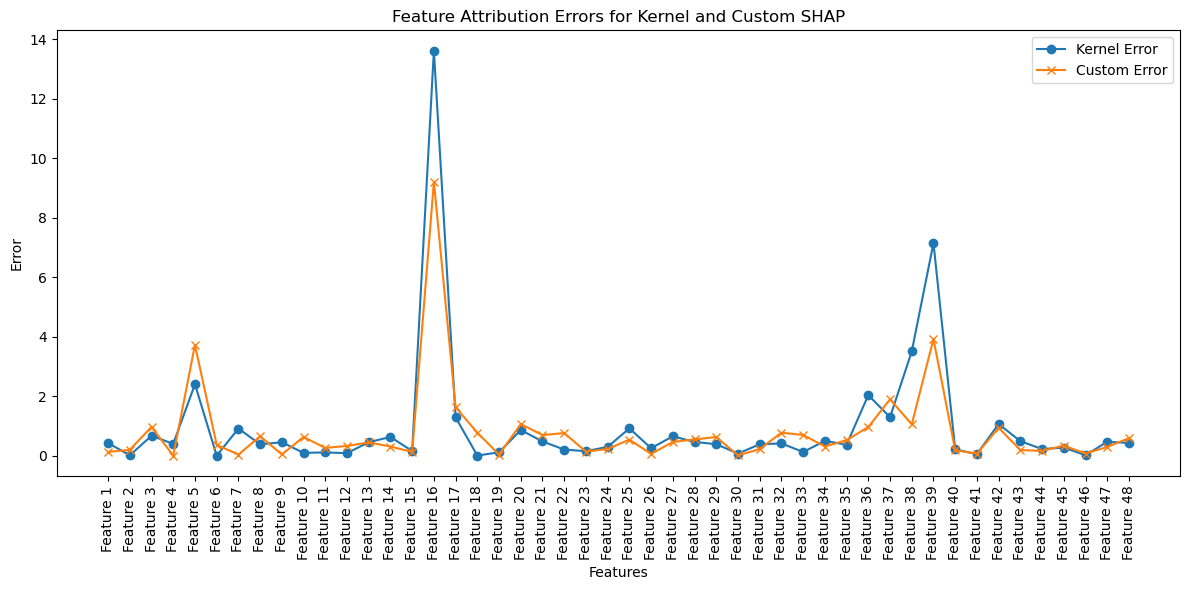

,Method,Time (s),MAE,MSE,SMAPE (%),R²
0,KernelExplainer,0.245503,0.962365,5.632425,90.153045,0.966891
1,Custom SHAP,0.388690,0.800422,2.751295,88.884045,0.983827


In [316]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import time
from sklearn.cluster import KMeans

# Generate a regression dataset
X, y = make_regression(n_samples=1000, n_features=48, noise=0.9, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Perform K-means clustering to obtain background data
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X_train)
background = kmeans.cluster_centers_
# background = X_train

# Select a test instance
test_instance = X_test[0]

# Compute SHAP values using TreeExplainer
start_time = time.time()
tree_explainer = shap.TreeExplainer(regressor)
tree_shap_values = tree_explainer.shap_values(test_instance.reshape(1, -1))[0]
tree_baseline = tree_explainer.expected_value[0] if isinstance(tree_explainer.expected_value, np.ndarray) else tree_explainer.expected_value
tree_time = time.time() - start_time

# Compute SHAP values using KernelExplainer
start_time = time.time()
kernel_explainer = shap.KernelExplainer(model=regressor.predict, data=background, algorithm='linear')
kernel_shap_values = kernel_explainer.shap_values(test_instance.reshape(1, -1))[0]
kernel_baseline = kernel_explainer.expected_value[0] if isinstance(kernel_explainer.expected_value, np.ndarray) else kernel_explainer.expected_value
kernel_time = time.time() - start_time

# Compute SHAP values using vectorized_weighted_shap (approximate)
start_time = time.time()
custom_shap_values, custom_baseline = vectorized_weighted_shap(
    model=regressor.predict,
    test_instance=test_instance,
    background_data=background,
    num_samples="auto",
    normalize_weights=True,
    use_random_sampling=False,
    use_paired_sampling=False,
    include_intermediate_factor=True,
    use_random_baseline=True,
    substitute_mean_for_continuous=False,  # Adjust based on your needs
    substitute_dummy_flip=False,           # Adjust based on your needs
    exact_shap=False                       # Set to True for exact Shapley values (if feasible)
)
custom_time = time.time() - start_time

# Compute metrics
true_prediction = regressor.predict(test_instance.reshape(1, -1))[0]
metrics = pd.DataFrame({
    "Method": ["KernelExplainer", "Custom SHAP"],
    "Time (s)": [kernel_time, custom_time],
    "MAE": [
        mean_absolute_error(tree_shap_values, kernel_shap_values),
        mean_absolute_error(tree_shap_values, custom_shap_values)
    ],
    "MSE": [
        mean_squared_error(tree_shap_values, kernel_shap_values),
        mean_squared_error(tree_shap_values, custom_shap_values)
    ],
    "SMAPE (%)": [
        np.mean(2 * np.abs(tree_shap_values - kernel_shap_values) / (np.abs(tree_shap_values) + np.abs(kernel_shap_values) + 1e-8)) * 100,
        np.mean(2 * np.abs(tree_shap_values - custom_shap_values) / (np.abs(tree_shap_values) + np.abs(custom_shap_values) + 1e-8)) * 100
    ],
    "R²": [
        r2_score(tree_shap_values, kernel_shap_values),
        r2_score(tree_shap_values, custom_shap_values)
    ]
})

# Plot feature attribution errors for Kernel and Custom SHAP
error_data = pd.DataFrame({
    "Feature": [f"Feature {i+1}" for i in range(X.shape[1])],
    "Kernel Error": np.abs(tree_shap_values - kernel_shap_values),
    "Custom Error": np.abs(tree_shap_values - custom_shap_values),
})

plt.figure(figsize=(12, 6))
plt.plot(error_data["Feature"], error_data["Kernel Error"], label="Kernel Error", marker="o")
plt.plot(error_data["Feature"], error_data["Custom Error"], label="Custom Error", marker="x")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Error")
plt.title("Feature Attribution Errors for Kernel and Custom SHAP")
plt.legend()
plt.tight_layout()
plt.show()

# Display the metrics DataFrame
metrics